# 데이터 시각화하기

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# 지도
# from geopy import distance # 거리 계산
# import geopy.distance
import folium
from folium.plugins import HeatMap

# plotly
import ipywidgets as widgets
from ipywidgets import interact

# 이걸 설정하면 Multiple Output이 가능함
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import chart_studio.plotly as py 
import plotly.express as px
import cufflinks as cf 
cf.go_offline(connected=True)

import plotly.graph_objects as go

## 서울시 구별 인포그래픽

In [20]:
# 데이터 불러오기
df = pd.read_csv('./dataset/서울시 구별 벚꽃나무 현황.csv')
df = df.set_index('자치구')
df

,왕벚나무
자치구,
종로구,422
중구,305
용산구,261
성동구,602
광진구,931
동대문구,747
중랑구,461
성북구,1757
강북구,496


In [2]:
# json
import json

In [3]:
# json 파일 로딩
geo_path = './dataset/skorea_municipalities_geo_simple.json'
geo_str = json.load(open(geo_path, encoding='utf-8'))

In [21]:
m = folium.Map(location=[37.5502, 126.982], zoom_start=11,
               tiles='Stamen Toner')

m.choropleth(geo_data=geo_str,
             data=df['왕벚나무'],
             columns=[df.index, df.왕벚나무],
             fill_color='PuRd',
             key_on='feature.id')
m

## 구별 벚나무 수

In [17]:
df = pd.read_csv('./dataset/서울시 구별 벚꽃나무 현황.csv')
df

,자치구,왕벚나무
0,강남구,2464
1,강동구,2323
2,강북구,496
3,강서구,2778
4,관악구,2556
5,광진구,931
6,구로구,2295
7,금천구,1051
8,노원구,1913
9,도봉구,2092


In [18]:
# 컬럼명 변경
df.rename(columns={'왕벚나무':'벚나무'}, inplace=True)
df

,자치구,벚나무
0,강남구,2464
1,강동구,2323
2,강북구,496
3,강서구,2778
4,관악구,2556
5,광진구,931
6,구로구,2295
7,금천구,1051
8,노원구,1913
9,도봉구,2092


<Figure size 1440x576 with 0 Axes>

<AxesSubplot:xlabel='자치구', ylabel='벚나무'>

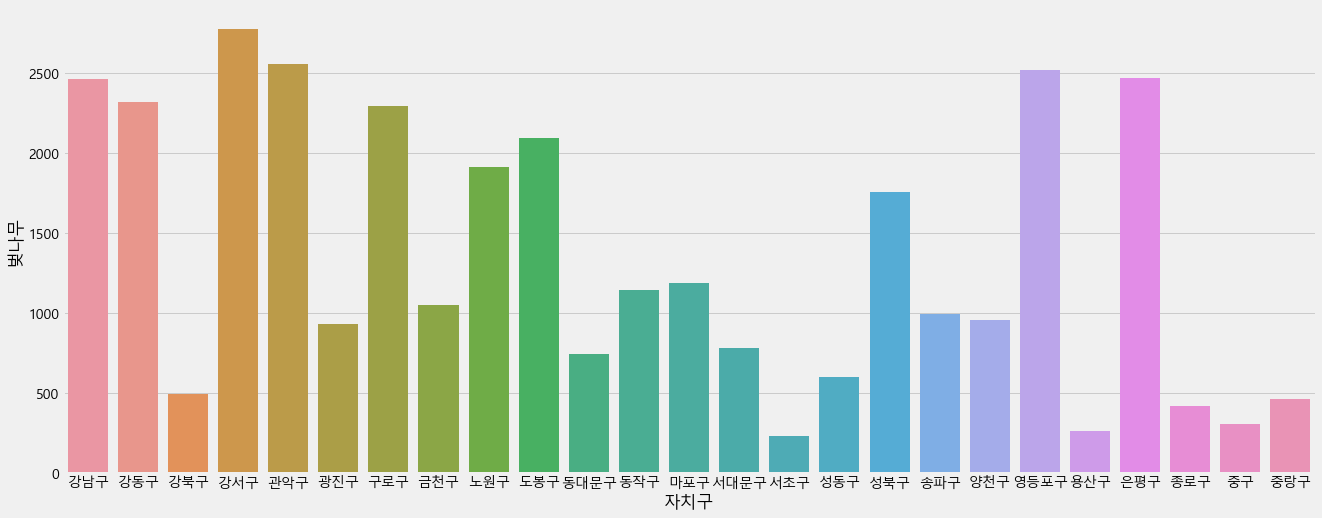

In [19]:
plt.figure(figsize=(20, 8))
sns.barplot(data=df, x='자치구', y='벚나무')
plt.show()

In [22]:
df.set_index('자치구').iplot(kind='bar')

## 지도 만들기

In [14]:
import chart_studio
chart_studio.tools.set_credentials_file(username='mingkipark', api_key='********')
from chart_studio.plotly import plot, iplot

In [10]:
df = pd.read_csv('./dataset/서울시 벚나무 위치정보.csv')
df.head()

,자치구,벚나무,LAT,LON
0,강남구,벚나무,37.4856982,127.0459174
1,강남구,벚나무,37.4894873,127.1052886
2,강남구,벚나무,37.4835354,127.0442866
3,강남구,벚나무,37.4840119,127.0447328
4,강남구,벚나무,37.491582,127.1023698


In [ ]:
# 서울시 37.55179808559256, 126.97682528549603

In [15]:
fig = px.scatter_mapbox(df, lat='LAT', lon='LON', zoom=10,
#                         size='방문횟수', size_max=20, 
#                         hover_name='사용장소', hover_data=['방문횟수', '사용금액'],
                        color='벚나무',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': 37.55179808559256, 'lon': 126.97682528549603})
fig.show()

In [16]:
# plot(fig, filename='seoul_cherryblossom_map', auto_open=True)

'https://plotly.com/~mingkipark/23/'